In [1]:
# Defining SoVI variables based on recent yearly releases. 

# SoVI 2014 
sovi_vars_2014 = [
    'MEDAGE', 'PERCAP', 'PPUNIT', 'QAGEDEP', 'QASIAN', 'QBLACK', 'QCVLUN', 'QED12LES',
    'QESL', 'QEXTRCT', 'QFEMALE', 'QFEMLBR', 'QFHH', 'QHISP', 'QHSEBRDN', 'QMOHO', 'QNATAM',
    'QNOAUTO', 'QUNINSUR', 'QPOVTY', 'QRENTER', 'QRICH200K', 'QSERV', 'QUNOCCHU', 'QSSBEN',
    'QFAM', 'MDHSEVAL', 'MDGRENT'
]

# SoVI 2019 - Removes MDHSEVAL, MDGRENT; replaces QFAM with QSNGPKIDS, adds QDISABL
sovi_vars_2019 = [
    'MEDAGE', 'PERCAP', 'PPUNIT', 'QAGEDEP', 'QASIAN', 'QBLACK', 'QCVLUN', 'QED12LES', 
    'QESL', 'QEXTRCT', 'QFEMALE', 'QFEMLBR', 'QFHH', 'QHISP', 'QHSEBRDN', 'QMOHO', 'QNATAM',
    'QNOAUTO', 'QUNINSUR', 'QPOVTY', 'QRENTER', 'QRICH200K', 'QSERV', 'QUNOCCHU', 'QSSBEN',
    'QDISABLE', 'QSNGPKIDS'
]

# 2014 and 2019 combined - QFAM and QSNGPKIDS are inverses of each other, so choose either
sovi_vars_com = [
    'MEDAGE', 'PERCAP', 'PPUNIT', 'QAGEDEP', 'QASIAN', 'QBLACK', 'QCVLUN', 'QED12LES', 
    'QESL', 'QEXTRCT', 'QFEMALE', 'QFEMLBR', 'QFHH', 'QHISP', 'QHSEBRDN', 'QMOHO', 'QNATAM',
    'QNOAUTO', 'QUNINSUR', 'QPOVTY', 'QRENTER', 'QRICH200K', 'QSERV', 'QUNOCCHU', 'QSSBEN',
    'QDISABLE', 'QSNGPKIDS', 'MDHSEVAL', 'MDGRENT'
]

# CHOOSE WHICH ONE:
sovi_vars = sovi_vars_2019


In [2]:
import pandas as pd
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
import numpy as np

# STANDARD SOVI PROCEDURE FOR ANY STATE'S CENSUS TRACTS #

# 1. DATA PREP AND CLEANING #

# Initialize dataframe
df_initial = pd.read_csv('../data/SoVI-vars-nationwide_2019.csv')

for col in sovi_vars:
    df_initial[col] = pd.to_numeric(df_initial[col], errors='coerce')
df_initial[sovi_vars] = df_initial[sovi_vars].mask(df_initial[sovi_vars] < 0, np.nan)

# 1.1. Choose state, if you want. Comment out to look at all tracts nationwide.
# Exclude Hawaii and Alaska if focusing on CONUS
exclude_states = ['Alaska', 'Hawaii']
df_initial = df_initial[~df_initial['State Name'].isin(exclude_states)]

state = 'Tennessee'
df_initial = df_initial[df_initial['State Name'] == state]

# 1.2. Filter out low population tracts. Thresholds can be adjusted. 
pop_threshold, hhold_threshold = 50, 50
pop_mask = (df_initial['TOTALPOP'] > pop_threshold) & (df_initial['TOTALHHOLD'] > hhold_threshold)

num_dropped = len(df_initial) - pop_mask.sum()

df_initial = df_initial[pop_mask]

print(f"Dropped {num_dropped} tracts with low population/households.")

# 1.3. Z-score scaling
scaler = StandardScaler()
df_scaled = pd.DataFrame(
    scaler.fit_transform(df_initial[sovi_vars]),
    columns=sovi_vars,
    index=df_initial.index
)

# 1.4. KNN Imputation
imputer = KNNImputer(n_neighbors=5)
df_imputed = pd.DataFrame(
    imputer.fit_transform(df_scaled),
    columns=sovi_vars,
    index=df_initial.index
)

num_imputed = df_initial[sovi_vars].isnull().sum().sum()
print(f"Total values imputed: {num_imputed}")


Dropped 26 tracts with low population/households.
Total values imputed: 0


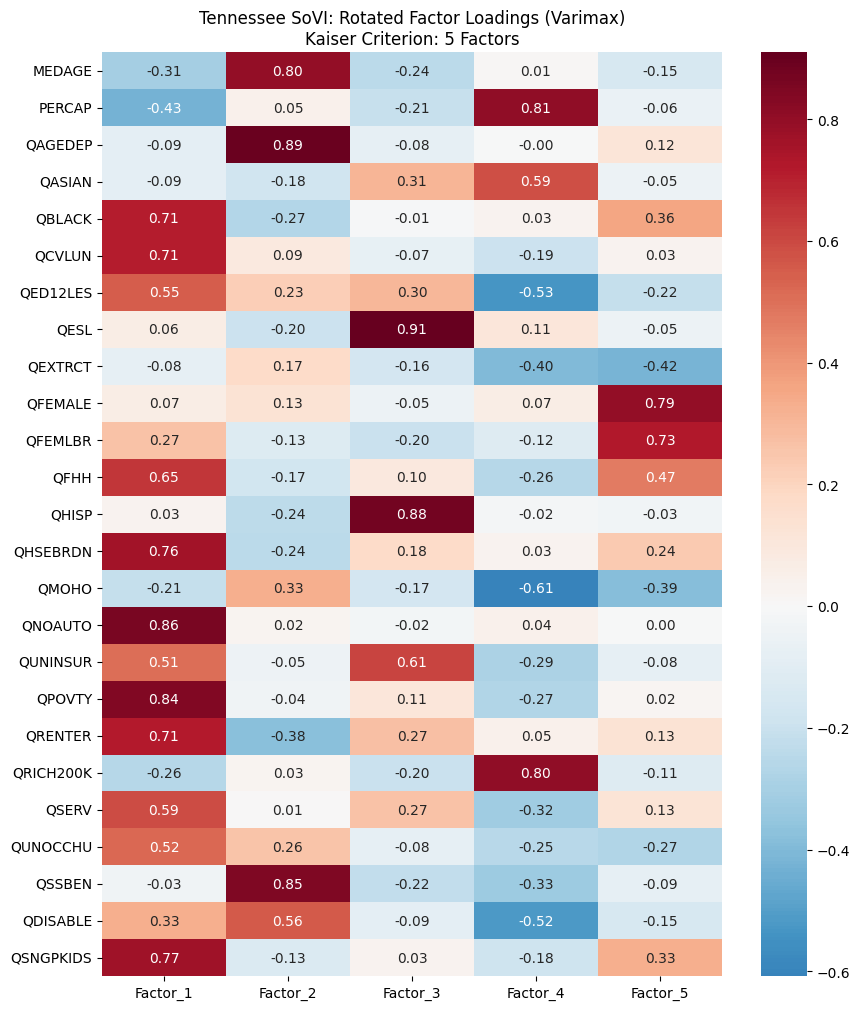

In [3]:
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from factor_analyzer.rotator import Rotator

# DROPPING VARIABLES #

# Removing certain variables can lead to increases in PCA performance, but be careful depending on
# the state of analysis. For example, in TN, removing QNATAM increases EV by about 4%, but other states
# have much more prominent Native American populations. Use the factor loading heatmap to decide.

# (Also make sure to run the first cell again when changing these out.)

vars_to_drop = ['QNATAM', 'PPUNIT']
sovi_vars = [v for v in sovi_vars if v not in vars_to_drop]



# 2. PRINCIPAL COMPONENTS ANALYSIS (PCA) #
pca_init = PCA()
pca_init.fit(df_imputed[sovi_vars])

# 2.1. Identify number of components based on Kaiser criterion
eigenvalues = pca_init.explained_variance_
n_comp = len(eigenvalues[eigenvalues > 1])

# 2.2. Extract unrotated loadings 
# Loadings = Eigenvectors * sqrt(Eigenvalues)
pca_final = PCA(n_components=n_comp)
pca_final.fit(df_imputed[sovi_vars])
unrotated_loadings = pca_final.components_.T * np.sqrt(pca_final.explained_variance_)

# 2.3. Apply Varimax rotation
rotator = Rotator(method='varimax')
rotated_loadings = rotator.fit_transform(unrotated_loadings)

# 2.4. Extract rotated loadings
loadings_rotated = pd.DataFrame(
    rotated_loadings,
    columns=[f'Factor_{i+1}' for i in range(n_comp)],
    index=sovi_vars
)

# 2.5. Heatmap
plt.figure(figsize=(10, 12))
sns.heatmap(loadings_rotated, annot=True, cmap='RdBu_r', center=0, fmt=".2f")
plt.title(f'{state} SoVI: Rotated Factor Loadings (Varimax)\nKaiser Criterion: {n_comp} Factors')
plt.show()


In [4]:
from scipy.stats.mstats import winsorize

# 3. CALCULATE SOVI SCORES #


# 3.1. Calculate factor score coefficients
# This is mathematically: (Correlation Matrix^-1) * Loadings
inv_corr = np.linalg.pinv(df_imputed[sovi_vars].corr())
weights = inv_corr.dot(rotated_loadings)

# 3.2. Calculate the actual factor scores for every tract
# Dot product of scaled data (tracts) and the weights (coefficients)
factor_scores = df_imputed[sovi_vars].dot(weights)
factor_scores.columns = [f'Factor_{i+1}' for i in range(n_comp)]

# 3.3. Apply any inversions (multiply factor by -1 if 'good' metrics (e.g. MDHSEVAL) are positive)
factors_to_invert = [4]  # Based on heatmap 
factor_scores_adjusted = factor_scores.copy()
for f_num in factors_to_invert:
    col_name = f'Factor_{f_num}'
    if col_name in factor_scores_adjusted.columns:
        factor_scores_adjusted[col_name] = factor_scores_adjusted[col_name] * -1

# 3.4. Final SoVI calculation
df_initial['SoVI_Score'] = factor_scores_adjusted.sum(axis=1)

# --- WINSORIZATION ---
df_initial['SoVI_Score'] = winsorize(df_initial['SoVI_Score'], limits=[0.01, 0.01])
# --------------------------

# Add adjusted scores to the main dataframe
adj_columns = {f'Factor_{i+1}': f'Factor_{i+1}' for i in range(n_comp)}
df_final = pd.concat([df_initial, factor_scores_adjusted.rename(columns=adj_columns)], axis=1)

print("\nFinal SoVI calculation complete!\n")

# Calculate individual and cumulative variance ratios
var_exp = pca_init.explained_variance_ratio_
cum_var_exp = np.cumsum(var_exp)

print(f"{'Factor':<10} | {'Expl. Var (%)':<15} | {'Cumul. Var (%)'}")
print("-" * 45)

for i in range(n_comp):
    print(f"Factor {i+1:<3} | {var_exp[i]*100:<15.2f}% | {cum_var_exp[i]*100:.2f}%")

print("")
print(df_final.head())

#df_final.to_csv('../results/SoVI-TN_2019.csv')
df_final.to_csv('../results/SoVI-USA_2019.csv')


Final SoVI calculation complete!

Factor     | Expl. Var (%)   | Cumul. Var (%)
---------------------------------------------
Factor 1   | 31.86          % | 31.86%
Factor 2   | 19.10          % | 50.97%
Factor 3   | 10.44          % | 61.40%
Factor 4   | 5.10           % | 66.50%
Factor 5   | 4.83           % | 71.33%

             GEOID State Name County Name  Year  TOTALPOP  TOTALHHOLD  \
60132  47001020100  Tennessee   Anderson   2019      3196        1510   
60133  47001020201  Tennessee   Anderson   2019      4080        1712   
60134  47001020202  Tennessee   Anderson   2019      3973        1731   
60135  47001020300  Tennessee   Anderson   2019      3851        1486   
60136  47001020400  Tennessee   Anderson   2019      4275        1877   

       QAGEDEP  QFEMALE  MEDAGE  QBLACK  ...  QDISABLE  QUNOCCHU  MDGRENT  \
60132   0.2369   0.5332    34.6  0.1974  ...    0.1665    0.1639      796   
60133   0.2341   0.5194    44.9  0.0358  ...    0.0816    0.0985      970   
60134  

In [6]:
import geopandas as gpd

# 1. Load the US-wide shapefile
shapefile_path = '/Users/maxbdixon/Documents/QGIS/cb_2019_us_tract_500k/cb_2019_us_tract_500k.shp'
gdf = gpd.read_file(shapefile_path)

# Ensure Shapefile GEOID is a clean 11-digit string
gdf['GEOID'] = gdf['GEOID'].astype(str).str.zfill(11)
gdf = gdf.set_index("GEOID")

# 2. Prepare your results - CRITICAL: Ensure 11-digit strings here too
results_indexed = df_final.copy()
# Force the GEOIDs from your original data to be 11-character strings
geoids = df_initial['GEOID'].astype(str).str.zfill(11)

if 'GEOID' in results_indexed.columns:
    results_indexed = results_indexed.drop(columns=['GEOID'])

results_indexed.index = geoids

# 3. Join geometry with results
# 'inner' join keeps only what exists in your results data
gdf_final = gdf[['geometry']].join(results_indexed, how='inner')

# 4. Debugging Check
unique_states = gdf_final.index.str[:2].unique()
print(f"Success! Joined data contains {len(gdf_final)} tracts across these State FIPS: {list(unique_states)}")

# 5. Export
if not gdf_final.empty:
    #output_file = '../results/SoVI_2019_Multistate.gpkg'
    output_file = f'../results/SoVI_2019_{state}.gpkg'
    gdf_final.reset_index().to_file(output_file, driver="GPKG")
    print(f"Saved to: {output_file}")
else:
    print("Join failed. No matching GEOIDs found between the shapefile and your results.")

Success! Joined data contains 1471 tracts across these State FIPS: ['47']
Saved to: ../results/SoVI_2019_Tennessee.gpkg


In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from scipy.spatial.distance import cdist, pdist
import numpy as np
import pandas as pd

# STANDARD K-MEANS QUALITY CHECKS #
# Checks results for a range of PCA components from the original SoVI and number of clusters
# This is VERY sensitive to change, since the "best" method relies on only using a portion of
# the PCA factors. For example, using the first 2 factors instead of the first 3 leads to all 
# the variance from Hispanic populations effectively disappearing, and not contributing to the
# clusters in a meaningful way. 


# 1. Setup
comp_range = range(6, 7) 
k_range = range(2, 11)    
results = []

# Assuming factor_scores is defined in your environment
scaler = StandardScaler()
X_full_scaled = scaler.fit_transform(factor_scores)

# Header for console output
print(f"{'Comp':<5} | {'K':<3} | {'Silh (↑)':<8} | {'D-B (↓)':<8} | {'Within (↓)':<10} | {'Inter (↑)'}")
print("-" * 65)

for n_comp in comp_range:
    # Slice the first N components
    X_subset = X_full_scaled[:, :n_comp]
    
    # Total Sum of Squares for Variance Explained calculation
    tss_subset = np.sum((X_subset - np.mean(X_subset, axis=0))**2)
    
    for k in k_range:
        km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
        labels = km.fit_predict(X_subset)
        centroids = km.cluster_centers_
        
        # --- Distance Metrics ---
        
        # 1. Within-Cluster Distance (Intra-cluster Cohesion)
        # Average Euclidean distance from each point to its assigned centroid
        pt_to_centroid_dist = np.min(cdist(X_subset, centroids, 'euclidean'), axis=1)
        avg_within_dist = np.mean(pt_to_centroid_dist)
        
        # 2. Inter-Cluster Distance (Separation)
        # Average Euclidean distance between all pairs of centroids
        if k > 1:
            centroid_distances = pdist(centroids, 'euclidean')
            avg_inter_dist = np.mean(centroid_distances)
        else:
            avg_inter_dist = 0
            
        # --- Standard Metrics ---
        sil = silhouette_score(X_subset, labels)
        db = davies_bouldin_score(X_subset, labels)
        var_exp = (1 - (km.inertia_ / tss_subset)) * 100

        results.append({
            'Components': n_comp,
            'K': k,
            'Silhouette': sil,
            'Davies_Bouldin': db,
            'Var_Exp_Pct': var_exp,
            'Avg_Within_Dist': avg_within_dist,
            'Avg_Inter_Dist': avg_inter_dist
        })
        
        print(f"{n_comp:<5} | {k:<3} | {sil:<8.3f} | {db:<8.3f} | {avg_within_dist:<10.3f} | {avg_inter_dist:.3f}")

summary_df = pd.DataFrame(results)

Comp  | K   | Silh (↑) | D-B (↓)  | Within (↓) | Inter (↑)
-----------------------------------------------------------------
6     | 2   | 0.248    | 2.115    | 1.823      | 1.878
6     | 3   | 0.203    | 1.747    | 1.653      | 2.246
6     | 4   | 0.237    | 1.437    | 1.548      | 2.942
6     | 5   | 0.228    | 1.303    | 1.445      | 3.135
6     | 6   | 0.212    | 1.249    | 1.364      | 3.070
6     | 7   | 0.215    | 1.230    | 1.316      | 3.150
6     | 8   | 0.221    | 1.195    | 1.278      | 3.245
6     | 9   | 0.223    | 1.188    | 1.253      | 3.530
6     | 10  | 0.189    | 1.253    | 1.210      | 3.315


In [8]:
import umap
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from scipy.spatial.distance import cdist, pdist
import pandas as pd
import numpy as np

# 1. Standardize 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(factor_scores)

# 2. UMAP Projection
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
X_embedded = reducer.fit_transform(X_scaled)

# 3. Setup for Variance Calculation
global_mean = np.mean(X_embedded, axis=0)
tss = np.sum((X_embedded - global_mean)**2)

results = []
k_range = range(2, 11)

# Updated Header to include Inter-cluster distance
print(f"{'K':<3} | {'Silh (↑)':<7} | {'DB (↓)':<7} | {'Expl %':<8} | {'Within (↓)':<10} | {'Inter (↑)'}")
print("-" * 65)

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=20, random_state=42)
    labels = km.fit_predict(X_embedded)
    centroids = km.cluster_centers_
    
    # Core Metrics
    sil = silhouette_score(X_embedded, labels)
    db_index = davies_bouldin_score(X_embedded, labels)
    
    # Variance Metric
    sse = km.inertia_ 
    explained_var = (1 - (sse / tss)) * 100
    
    # Distance Metrics
    avg_within = np.mean(np.min(cdist(X_embedded, centroids, 'euclidean'), axis=1))
    # 'pdist' calculates pairwise distances between all centroids
    avg_inter = np.mean(pdist(centroids, 'euclidean')) if k > 1 else 0

    results.append({
        'K': k, 
        'Silhouette': sil, 
        'DB_Index': db_index,
        'Expl_Var': explained_var,
        'Avg_Inter': avg_inter
    })
    
    print(f"{k:<3} | {sil:<7.3f} | {db_index:<7.3f} | {explained_var:<7.1f}% | {avg_within:<10.3f} | {avg_inter:.3f}")

summary_df = pd.DataFrame(results)

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


K   | Silh (↑) | DB (↓)  | Expl %   | Within (↓) | Inter (↑)
-----------------------------------------------------------------
2   | 0.459   | 0.840   | 53.4   % | 2.272      | 5.359
3   | 0.478   | 0.746   | 72.0   % | 1.793      | 5.229
4   | 0.418   | 0.827   | 78.8   % | 1.547      | 5.143
5   | 0.392   | 0.923   | 82.9   % | 1.396      | 5.111
6   | 0.414   | 0.873   | 86.4   % | 1.246      | 4.902
7   | 0.425   | 0.767   | 88.7   % | 1.142      | 4.922
8   | 0.420   | 0.780   | 90.6   % | 1.038      | 4.944
9   | 0.419   | 0.743   | 91.8   % | 0.971      | 5.003
10  | 0.418   | 0.748   | 92.8   % | 0.909      | 4.952


In [11]:
import pandas as pd
import geopandas as gpd
import numpy as np
import umap
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist, pdist

# UMAP CLUSTERING CONTINUED #
# This version in theory allows for even greater numbers of clusters, but it seems like 5 or 6 is
# still the best option. However, Using 9 or 10 may be somewhat comparable to SoVI as a continuous 
# index, since it offers high granularity AND good quality metrics. I may experiment with 9 or 10 
# for the rural/urban part, just to see if differences can be teased out.


# --- 1. SETTINGS ---
N_COMPONENTS = 5  
K_CLUSTERS = 6
output_path = f"../results/K-SoVI_UMAP_2019_{state}.gpkg"

# Load data
gdf = gpd.read_file(f'../results/SoVI_2019_{state}.gpkg')


# --- 2. UMAP MANIFOLD PROJECTION ---
# Cluster based on the 5 factors
active_pc = [f'Factor_{i+1}' for i in range(N_COMPONENTS)]
X_raw = gdf[active_pc].values

# Standardize factors
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# Reduce to 2D Manifold for cleaner cluster separation
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
X_embedded = reducer.fit_transform(X_scaled)

# --- 3. CLUSTERING ON EMBEDDED SPACE ---
km = KMeans(n_clusters=K_CLUSTERS, init='k-means++', n_init=100, random_state=42)
gdf['raw_cluster'] = km.fit_predict(X_embedded)

# --- 4. SORTING BY POVERTY (1=Low, 6=High) ---
poverty_rank = gdf.groupby('raw_cluster')['PERCAP'].mean().sort_values(ascending=False).index
cluster_map = {old: i + 1 for i, old in enumerate(poverty_rank)}
gdf['SoVI_Cluster'] = gdf['raw_cluster'].map(cluster_map)

# --- 5. EXPORT ---
gdf.to_file(output_path, driver="GPKG")

# --- 6. PRINTING THE RESULTS ---
print(f"--- SUCCESS: {len(gdf)} TRACTS PROCESSED VIA UMAP ---")

available_vars = [v for v in sovi_vars if v in gdf.columns]

if available_vars:
    print("\n--- MEAN CENSUS VARIABLES BY CLUSTER (UNSCALED) ---")
    # Group by the sorted cluster, calculate means, and transpose
    summary_table = gdf.groupby('SoVI_Cluster')[available_vars].mean().T
    summary_table.columns = [f'Cluster {int(c)}' for c in summary_table.columns]
    
    try:
        display(summary_table.round(3))
    except NameError:
        print(summary_table.round(3))

print("\n--- CLUSTER SIZES ---")
print(gdf['SoVI_Cluster'].value_counts().sort_index())

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


--- SUCCESS: 1471 TRACTS PROCESSED VIA UMAP ---

--- MEAN CENSUS VARIABLES BY CLUSTER (UNSCALED) ---


,Cluster 1,Cluster 2,Cluster 3,Cluster 4,Cluster 5,Cluster 6
MEDAGE,38.246,41.086,45.968,43.506,35.764,33.200
PERCAP,47998.870,31063.404,28329.347,23678.421,23527.588,20827.874
QAGEDEP,0.199,0.222,0.286,0.240,0.209,0.183
QASIAN,0.040,0.009,0.008,0.003,0.021,0.013
QBLACK,0.116,0.054,0.080,0.035,0.240,0.625
QCVLUN,0.030,0.038,0.058,0.062,0.061,0.105
QED12LES,0.045,0.098,0.142,0.180,0.172,0.162
QESL,0.030,0.010,0.012,0.009,0.090,0.028
QEXTRCT,0.003,0.009,0.012,0.037,0.005,0.003
QFEMALE,0.514,0.515,0.524,0.486,0.516,0.526



--- CLUSTER SIZES ---
SoVI_Cluster
1    239
2    218
3    259
4    285
5    240
6    230
Name: count, dtype: int64


In [28]:
import pandas as pd
import geopandas as gpd
import numpy as np
from sklearn.cluster import KMeans

# This is the standard k-means on PCA components method. Like I said above, it's very sensitive
# to the number of factors you select. Quality metrics are not amazing in most scenarios, especially
# considering the tradeoff that must be made when using a limited number of PCA factors to cluster.


# --- 1. SETTINGS ---
N_COMPONENTS = 5  
K_CLUSTERS = 5
BINS = K_CLUSTERS
BIN_LABEL = f'SoVI_Bin_{BINS}'

# Load the file you already have
gdf = gpd.read_file('../results/SoVI_2019.gpkg')

# --- 2. CLUSTERING ---
active_pc = [f'Factor_{i+1}' for i in range(N_COMPONENTS)]
X = gdf[active_pc].values 

km = KMeans(n_clusters=K_CLUSTERS, init='k-means++', n_init=100, random_state=42)
gdf['raw_cluster'] = km.fit_predict(X)

# Rank by Poverty so Cluster 6 is always the "highest vulnerability" 
# This makes the comparison to SoVI_Score logical.
poverty_rank = gdf.groupby('raw_cluster')['QPOVTY'].mean().sort_values().index
cluster_map = {old: i + 1 for i, old in enumerate(poverty_rank)}
gdf['SoVI_Cluster'] = gdf['raw_cluster'].map(cluster_map)

# --- 3. MISMATCH CALCULATION ---
# Bin the existing SoVI_Score into sextiles
gdf[BIN_LABEL] = pd.qcut(gdf['SoVI_Score'], BINS, labels=False) + 1

# Mismatch = are the cluster ID and the SoVI Bin different?
gdf['mismatch'] = (gdf[BIN_LABEL] != gdf['SoVI_Cluster']).astype(int)
gdf['mismatch_diff'] = abs(gdf[BIN_LABEL] - gdf['SoVI_Cluster'])

# --- 4. EXPORT ---
output_path = "../results/K-SoVI_2019.gpkg"
gdf.to_file(output_path, driver="GPKG")

# --- 5. PRINTING THE RESULTS (VERIFICATION) ---
print(f"--- SUCCESS: {len(gdf)} TRACTS PROCESSED ---")
print(f"Mismatch Rate: {(gdf['mismatch'].mean() * 100):.2f}%")

available_vars = [v for v in sovi_vars if v in gdf.columns]

if available_vars:
    print("\n--- MEAN CENSUS VARIABLES BY CLUSTER ---")
    display(gdf.groupby('SoVI_Cluster')[available_vars].mean().round(3).T)

--- SUCCESS: 1471 TRACTS PROCESSED ---
Mismatch Rate: 62.54%

--- MEAN CENSUS VARIABLES BY CLUSTER ---


SoVI_Cluster,1,2,3,4,5
MEDAGE,40.923,37.225,44.489,33.489,34.265
PERCAP,55754.630,29183.649,25410.213,21718.565,17304.946
QAGEDEP,0.219,0.204,0.257,0.189,0.207
QASIAN,0.046,0.016,0.005,0.036,0.007
QBLACK,0.086,0.198,0.046,0.224,0.746
QCVLUN,0.027,0.046,0.061,0.059,0.136
QED12LES,0.039,0.099,0.165,0.223,0.206
QESL,0.024,0.028,0.010,0.188,0.021
QEXTRCT,0.003,0.005,0.026,0.004,0.004
QFEMALE,0.510,0.524,0.500,0.492,0.531


In [27]:
import pandas as pd
import geopandas as gpd
import numpy as np
from sklearn.cluster import KMeans

# This is just a duplicate of the above code to compare different components and k's. 


# --- 1. SETTINGS ---
N_COMPONENTS = 5  
K_CLUSTERS = 5
BINS = K_CLUSTERS
BIN_LABEL = f'SoVI_Bin_{BINS}'

# Load the file you already have
gdf = gpd.read_file('../results/SoVI_2019.gpkg')

# --- 2. CLUSTERING ---
active_pc = [f'Factor_{i+1}' for i in range(N_COMPONENTS)]
X = gdf[active_pc].values 

km = KMeans(n_clusters=K_CLUSTERS, init='k-means++', n_init=100, random_state=42)
gdf['raw_cluster'] = km.fit_predict(X)

# Rank by Poverty so Cluster 6 is always the "highest vulnerability" 
# This makes the comparison to SoVI_Score logical.
poverty_rank = gdf.groupby('raw_cluster')['QPOVTY'].mean().sort_values().index
cluster_map = {old: i + 1 for i, old in enumerate(poverty_rank)}
gdf['SoVI_Cluster'] = gdf['raw_cluster'].map(cluster_map)

# --- 3. MISMATCH CALCULATION ---
# Bin the existing SoVI_Score into sextiles
gdf[BIN_LABEL] = pd.qcut(gdf['SoVI_Score'], BINS, labels=False) + 1

# Mismatch = are the cluster ID and the SoVI Bin different?
gdf['mismatch'] = (gdf[BIN_LABEL] != gdf['SoVI_Cluster']).astype(int)
gdf['mismatch_diff'] = abs(gdf[BIN_LABEL] - gdf['SoVI_Cluster'])

# --- 4. EXPORT ---
output_path = "../results/K_adj-SoVI_2019.gpkg"
gdf.to_file(output_path, driver="GPKG")

# --- 5. PRINTING THE RESULTS (VERIFICATION) ---
print(f"--- SUCCESS: {len(gdf)} TRACTS PROCESSED ---")
print(f"Mismatch Rate: {(gdf['mismatch'].mean() * 100):.2f}%")

available_vars = [v for v in sovi_vars if v in gdf.columns]

if available_vars:
    print("\n--- MEAN CENSUS VARIABLES BY CLUSTER ---")
    display(gdf.groupby('SoVI_Cluster')[available_vars].mean().round(3).T)

--- SUCCESS: 1471 TRACTS PROCESSED ---
Mismatch Rate: 62.54%

--- MEAN CENSUS VARIABLES BY CLUSTER ---


SoVI_Cluster,1,2,3,4,5
MEDAGE,40.923,37.225,44.489,33.489,34.265
PERCAP,55754.630,29183.649,25410.213,21718.565,17304.946
QAGEDEP,0.219,0.204,0.257,0.189,0.207
QASIAN,0.046,0.016,0.005,0.036,0.007
QBLACK,0.086,0.198,0.046,0.224,0.746
QCVLUN,0.027,0.046,0.061,0.059,0.136
QED12LES,0.039,0.099,0.165,0.223,0.206
QESL,0.024,0.028,0.010,0.188,0.021
QEXTRCT,0.003,0.005,0.026,0.004,0.004
QFEMALE,0.510,0.524,0.500,0.492,0.531


In [ ]:
import pandas as pd
import geopandas as gpd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score
from scipy.spatial.distance import pdist, squareform

# This was another thing I tried before UMAP - weighting the components during clustering based
# on their relative explained variance. It doesn't really fix the underlying issues, though.


# --- 1. SETTINGS & WEIGHTS ---
N_COMPONENTS = 5
K_CLUSTERS = 5
BINS = K_CLUSTERS

weights = pca_init.explained_variance_ratio_[:N_COMPONENTS]
#weights = np.array([0.3069, 0.1843, 0.1032, 0.0584, 0.0471, 0.0425]) 

gdf = gpd.read_file('../results/SoVI_2019.gpkg')

# --- 2. WEIGHTED PREP ---
active_pc = [f'Factor_{i+1}' for i in range(N_COMPONENTS)]
X_raw = gdf[active_pc].values

# Apply weights: This prioritizes the "strongest" PCA signals
X_weighted = X_raw * weights

# --- 3. CLUSTERING ---
km = KMeans(n_clusters=K_CLUSTERS, init='k-means++', n_init=100, random_state=42)
gdf['raw_cluster'] = km.fit_predict(X_weighted)

# --- 4. SORT BY POVERTY ---
# We calculate mean poverty per raw cluster, sort them, and re-map
poverty_rank = gdf.groupby('raw_cluster')['PERCAP'].mean().sort_values(ascending=False).index
cluster_map = {old: i + 1 for i, old in enumerate(poverty_rank)}
gdf['SoVI_Cluster'] = gdf['raw_cluster'].map(cluster_map)

# --- 5. METRICS CALCULATION ---

# 1. Standard Metrics
tss_weighted = np.sum((X_weighted - np.mean(X_weighted, axis=0))**2)
weighted_ev_pct = (1 - (km.inertia_ / tss_weighted)) * 100
sil_score = silhouette_score(X_weighted, gdf['SoVI_Cluster'])
db_index = davies_bouldin_score(X_weighted, gdf['SoVI_Cluster'])

# 2. Xie-Beni (XB) Index Calculation
# Compactness: sum of squared distances of points to their cluster centers (Inertia)
compactness = km.inertia_

# Separation: minimum squared distance between any two cluster centers
centers = km.cluster_centers_
center_dists = pdist(centers, 'sqeuclidean') # Squared Euclidean distance
min_separation = np.min(center_dists)

# XB = Compactness / (n_samples * min_separation)
xb_index = compactness / (len(X_weighted) * min_separation)

print(f"--- Weighted Clustering Metrics (K={K_CLUSTERS}) ---")
print(f"Silhouette Score (↑): {sil_score:.3f}")
print(f"Davies-Bouldin Index (↓): {db_index:.3f}")
print(f"Xie-Beni Index (↓): {xb_index:.4f}")
print(f"Weighted Model EV% (↑): {weighted_ev_pct:.2f}%")

# --- 6. SOVI BINNING FOR COMPARISON ---
gdf[f'SoVI_Bin_{BINS}'] = pd.qcut(gdf['SoVI_Score'], BINS, labels=False) + 1
gdf['mismatch'] = (gdf[f'SoVI_Bin_{BINS}'] != gdf['SoVI_Cluster']).astype(int)
gdf['mismatch_diff'] = abs((gdf[f'SoVI_Bin_{BINS}'] - gdf['SoVI_Cluster']).astype(int))

# --- 7. RESULTS & MEANS ---
print(gdf['SoVI_Cluster'].value_counts().sort_index())

# Verification Table
available_vars = [v for v in sovi_vars if v in gdf.columns]

print("\n--- FINAL CLUSTER PROFILES ---")
# This table shows the real-world means for your 6 sorted clusters
means_table = gdf.groupby('SoVI_Cluster')[available_vars + active_pc].mean()
display(means_table.T.round(3))

# --- 8. EXPORT ---
gdf.to_file("../results/K-SoVI_Weighted.gpkg", driver="GPKG")

--- Weighted Clustering Metrics (K=5) ---
Silhouette Score (↑): 0.263
Davies-Bouldin Index (↓): 1.117
Xie-Beni Index (↓): 0.7440
Weighted Model EV% (↑): 70.29%
SoVI_Cluster
1    397
2    506
3    280
4    199
5     89
Name: count, dtype: int64

--- FINAL CLUSTER PROFILES ---


SoVI_Cluster,1,2,3,4,5
MEDAGE,36.139,43.964,44.360,32.527,35.225
PERCAP,33251.340,32116.202,26808.571,22078.261,15895.292
QAGEDEP,0.185,0.251,0.273,0.173,0.219
QASIAN,0.025,0.011,0.012,0.015,0.008
QBLACK,0.143,0.052,0.099,0.453,0.791
QCVLUN,0.039,0.043,0.072,0.078,0.160
QED12LES,0.089,0.120,0.178,0.160,0.234
QESL,0.044,0.014,0.026,0.046,0.024
QEXTRCT,0.007,0.017,0.020,0.005,0.004
QFEMALE,0.509,0.512,0.515,0.510,0.530


In [ ]:
import geopandas as gpd
import pandas as pd

# This is just to check the mean values of a specific tract. I'm using this to help make figures.


# 1. Configuration
file_path = "/Users/maxbdixon/Documents/GitHub/SoVI-clustering/V2/results/K-SoVI_2019.gpkg"

def analyze_tract_comparison(geoid, path, variables):
    # Load the data
    gdf = gpd.read_file(path)
    
    # Ensure GEOID is a string for consistent slicing
    gdf['GEOID'] = gdf['GEOID'].astype(str)
    
    # Extract the specific tract
    tract = gdf[gdf['GEOID'] == str(geoid)]
    
    if tract.empty:
        print(f"Error: GEOID {geoid} not found in dataset.")
        return

    # Identify groupings
    cluster = tract['SoVI_Cluster'].iloc[0]
    sovi_bin = tract['SoVI_Bin_6'].iloc[0]
    county_fips = str(geoid)[:5]
    
    # 2. Calculate Group Means
    # Cluster Mean
    cluster_mean = gdf[gdf['SoVI_Cluster'] == cluster][variables].mean()
    
    # Bin Mean
    bin_mean = gdf[gdf['SoVI_Bin_6'] == sovi_bin][variables].mean()
    
    # County Mean (Filter by first 5 digits of GEOID)
    county_mean = gdf[gdf['GEOID'].str.startswith(county_fips)][variables].mean()
    
    # 3. Create Comparison Table
    comparison = pd.DataFrame({
        'Variable': variables,
        'Tract_Value': tract[variables].iloc[0].values,
        'Cluster_Mean': cluster_mean.values,
        'Bin_Mean': bin_mean.values,
        'County_Mean': county_mean.values
    })
    
    # Add a 'Diff_from_County' column to see local outliers
    comparison['Vs_County_%'] = ((comparison['Tract_Value'] - comparison['County_Mean']) / comparison['County_Mean'] * 100).round(2)

    print(f"--- Analysis for Tract: {geoid} ---")
    print(f"Location Context: Cluster {cluster} | SoVI Bin {sovi_bin} | County {county_fips}\n")
    print(comparison.to_string(index=False))
    
    return comparison

# Example Usage:
df_results = analyze_tract_comparison("47157001200", file_path, sovi_vars)


--- Analysis for Tract: 47157001200 ---
Location Context: Cluster 1 | SoVI Bin 6 | County 47157

 Variable  Tract_Value  Cluster_Mean     Bin_Mean  County_Mean  Vs_County_%
   MEDAGE      33.5000     36.680398    38.605306    36.595833        -8.46
   PERCAP   18289.0000  33500.460227 19950.726531 27735.745370       -34.06
   PPUNIT       3.0500      2.659687     2.524163     2.598333        17.38
  QAGEDEP       0.1732      0.189408     0.247827     0.209161       -17.19
   QASIAN       0.0057      0.023204     0.011883     0.020215       -71.80
   QBLACK       0.2135      0.126611     0.408662     0.584331       -63.46
   QCVLUN       0.0477      0.037652     0.096239     0.090983       -47.57
 QED12LES       0.2648      0.088047     0.208319     0.140046        89.08
     QESL       0.1532      0.038523     0.059378     0.035049       337.10
  QEXTRCT       0.0000      0.007990     0.006923     0.002450      -100.00
  QFEMALE       0.4822      0.509339     0.540328     0.526938     

In [ ]:
import geopandas as gpd
import pandas as pd

# Duplicate of the above code block


# 1. Configuration
file_path = "/Users/maxbdixon/Documents/GitHub/SoVI-clustering/V2/results/K-SoVI_2019.gpkg"

def analyze_tract_comparison(geoid, path, variables):
    # Load the data
    gdf = gpd.read_file(path)
    
    # Ensure GEOID is a string for consistent slicing
    gdf['GEOID'] = gdf['GEOID'].astype(str)
    
    # Extract the specific tract
    tract = gdf[gdf['GEOID'] == str(geoid)]
    
    if tract.empty:
        print(f"Error: GEOID {geoid} not found in dataset.")
        return

    # Identify groupings
    cluster = tract['SoVI_Cluster'].iloc[0]
    sovi_bin = tract['SoVI_Bin_6'].iloc[0]
    county_fips = str(geoid)[:5]
    
    # 2. Calculate Group Means
    # Cluster Mean
    cluster_mean = gdf[gdf['SoVI_Cluster'] == cluster][variables].mean()
    
    # Bin Mean
    bin_mean = gdf[gdf['SoVI_Bin_6'] == sovi_bin][variables].mean()
    
    # County Mean (Filter by first 5 digits of GEOID)
    county_mean = gdf[gdf['GEOID'].str.startswith(county_fips)][variables].mean()
    
    # 3. Create Comparison Table
    comparison = pd.DataFrame({
        'Variable': variables,
        'Tract_Value': tract[variables].iloc[0].values,
        'Cluster_Mean': cluster_mean.values,
        'Bin_Mean': bin_mean.values,
        'County_Mean': county_mean.values
    })
    
    # Add a 'Diff_from_County' column to see local outliers
    comparison['Vs_County_%'] = ((comparison['Tract_Value'] - comparison['County_Mean']) / comparison['County_Mean'] * 100).round(2)

    print(f"--- Analysis for Tract: {geoid} ---")
    print(f"Location Context: Cluster {cluster} | SoVI Bin {sovi_bin} | County {county_fips}\n")
    print(comparison.to_string(index=False))
    
    return comparison

# Example Usage:
df_results = analyze_tract_comparison("47065002600", file_path, sovi_vars)


--- Analysis for Tract: 47065002600 ---
Location Context: Cluster 3 | SoVI Bin 6 | County 47065

 Variable  Tract_Value  Cluster_Mean     Bin_Mean  County_Mean  Vs_County_%
   MEDAGE      39.4000     47.350000    38.605306    39.622500        -0.56
   PERCAP   15042.0000  30848.658537 19950.726531 32174.537500       -53.25
   PPUNIT       2.7200      2.391951     2.524163     2.388375        13.88
  QAGEDEP       0.2268      0.292524     0.247827     0.225510         0.57
   QASIAN       0.0000      0.010796     0.011883     0.017841      -100.00
   QBLACK       0.3902      0.062121     0.408662     0.221094        76.49
   QCVLUN       0.1016      0.062636     0.096239     0.056975        78.32
 QED12LES       0.3413      0.154404     0.208319     0.116890       191.98
     QESL       0.2483      0.014723     0.059378     0.032721       658.83
  QEXTRCT       0.0000      0.018202     0.006923     0.002936      -100.00
  QFEMALE       0.5156      0.517478     0.540328     0.518359     